<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week12/Day3/MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Project: Predicting Heart Disease Using Logistic Regression
Objective: to predict if a patient has heart disease, based on various medical attributes

In [14]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,  roc_auc_score, roc_curve

print ("importations done!")

importations done!


# 1. Data Preparation
Perform EDA to understand the dataset.

Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.

In [15]:
# Load data

df = pd.read_csv('heart_disease_uci.csv')

In [16]:
# EDA

print ('\nfirst 5 rows')
print(df.head())

print ('\nShape database')  # dataset of 920 pacients x 16 columns
print(df.shape)

print()
print(f'Duplicates: {df.duplicated().any()}')  #no duplicates


first 5 rows
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal  

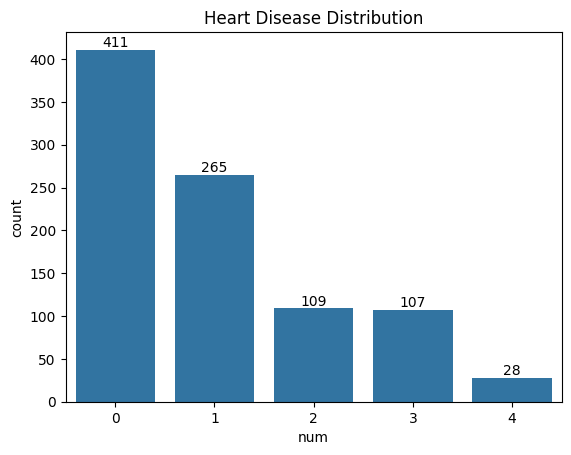

In [17]:
# num distribution

ax = sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

# we need to convert to 0 = no disease (healthy), 1 = 1 + 2 + 3 + 4 = yes (heart disease)

In [18]:
print ('\nInfo')
print(df.info())


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None


In [19]:
missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_report = missing_report.sort_values(by='Missing Values', ascending=False)

missing_report['Percentage (%)'] = missing_report['Percentage (%)'].round(1)

missing_report = missing_report[missing_report['Missing Values'] > 0]

missing_report

# The dataset contains significant missing values, particularly in relevant variables such as ca and thal.

,Missing Values,Percentage (%)
ca,611,66.4
thal,486,52.8
slope,309,33.6
fbs,90,9.8
oldpeak,62,6.7
trestbps,59,6.4
exang,55,6.0
thalch,55,6.0
chol,30,3.3
restecg,2,0.2


In [20]:
# COPY

df2 = df.copy()


In [21]:
# Roadmap for Data types & Treatment Missing Values

# To Drop
#  0   id
#  3   dataset   hospital's geography
#  15  num

# Numerical
#  1   age       patient age
#  5   trestbps  Resting blood pressure    0 = nan, blanks = nan, impute with median
#  6   chol      colesterol   0 = nan, blanks = nan, impute with median
#  9   thalch    Maximum heart rate achieved, impute with median    how the heart responds (physical capacity)
#  11  oldpeak   ST depression during exercis  blanks, impute with median
#  13  ca        Number of major vessels (vasos) , NA 66.4%, Unknown

# Categorical
#  4   cp        chest pain type   to category
#  8   restecg   resting ECG results, to category , impute with Mode
#  12  slope     Slope of ST segment, NA 33.6%, Unknown, to category
#  14  thal      defect, Thalassemia condition , NA 52.8%, Unknown, to category

# Binary
#  2   sex       Female 0 - Male 1
#  7   fbs       fasting blood sugar TRUE 1, FALSE 0, impute with Mode
#  10  exang     exercise induced angina TRUE 1, FALSE 0, impute with Mode = si duele el pecho con esfuerzo (síntoma directo)

# target
#  16  num --> target


'''  Numerical variables are imputed using the median to reduce the impact of outliers and skewed distributions.
Invalid values of zeros in clinical measurements (cholesterol and blood pressure) are treated as missing.

Categorical variables are imputed using either the mode or a new "Unknown" category to preserve missingness
as potential information. '''

'  Numerical variables are imputed using the median to reduce the impact of outliers and skewed distributions.\nInvalid values of zeros in clinical measurements (cholesterol and blood pressure) are treated as missing.\n\nCategorical variables are imputed using either the mode or a new "Unknown" category to preserve missingness\nas potential information. '

In [22]:
# Target = to binary

df2['target'] = (df2['num'] > 0).astype(int)

class_names = {0: 'HEALTHY', 1: 'HEART DISEASE'}

counts = df2['target'].value_counts().rename(index=class_names)
percent = df2['target'].value_counts(normalize=True).rename(index=class_names) * 100

result = pd.DataFrame({
    'count': counts,
    'percentage': percent.round(1)
})

print('How many patients with Heart Disease does the dataset have?') # ~  55.3% , slight imbalance
print(result)

How many patients with Heart Disease does the dataset have?
               count  percentage
target                          
HEART DISEASE    509        55.3
HEALTHY          411        44.7


In [23]:
# Drop irrelevant columns
df2 = df2.drop(columns=['id', 'num', 'dataset'])

# DOMAIN-BASED CLEANING

In [24]:
#  Resting blood pressure and cholesterol in 0 -> to missing
df2[['trestbps', 'chol']] = df2[['trestbps', 'chol']].replace(0, np.nan)

In [25]:
# missing as nan
df2['ca'] = df2['ca'].fillna(np.nan)

In [26]:
df2['ca'] = df2['ca'].astype(float)  # float accepts nans
df2['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [27]:
# CATEGORICAL --> NA is "Unknown"
df2['slope'] = df2['slope'].fillna('Unknown')
df2['thal'] = df2['thal'].fillna('Unknown')

print(df2['slope'].unique())
print(df2['thal'].unique())

['downsloping' 'flat' 'upsloping' 'Unknown']
['fixed defect' 'normal' 'reversable defect' 'Unknown']


In [28]:
df2['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [29]:
#sex encoding

df2['sex'] = df2['sex'].str.strip().str.lower()
df2['sex'] = df2['sex'].map({'male': 1, 'female': 0})
print(df2['sex'].value_counts())

sex
1    726
0    194
Name: count, dtype: int64


In [30]:
print(df2['fbs'].unique())
print(df2['exang'].unique())

[True False nan]
[False True nan]


In [31]:
# cleaning on binaries
# binaries basic normalization

df2['fbs'] = df2['fbs'].astype(str).str.strip().str.lower()
df2['exang'] = df2['exang'].astype(str).str.strip().str.lower()

df2['fbs'] = df2['fbs'].map({'true': 1, 'false': 0})
df2['exang'] = df2['exang'].map({'true': 1, 'false': 0})

# chequeo obligatorio
print(df2[['fbs','exang']].isna().sum())
# fbs      90
# exang    55

fbs      90
exang    55
dtype: int64


In [32]:
df2.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [33]:
# Define variables
y = df2['target']
X = df2.drop('target', axis=1)

In [34]:
# Identify column types
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_features = ['cp', 'restecg', 'slope', 'thal']
binary_features = ['sex', 'fbs', 'exang', ]

In [35]:
#  Preprocessing

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # missing --> median
    ('scaler', StandardScaler())          # StandardScaler for numerical variables
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),    # missing --> mode
    ('onehot', OneHotEncoder(drop='first'))        # OneHotEncoder for categorical variales
])

binary_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')) ])    # missing --> mode

# COLUMN TRANSFORMER

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('bin', binary_transformer, binary_features)
])

# 2. Model Training
Split the dataset into a training set and a testing set.

Train a logistic regression model on the training set.

In [36]:
# SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  #same proportion, maintaining the class ratio
)

print()
print("Train shape:", X_train.shape)  #80%
print("Test shape:", X_test.shape)    #20%

print()
print(y_train.mean().round(2)) # ~0.55
print(y_test.mean().round(2))  # ~0.55


Train shape: (736, 13)
Test shape: (184, 13)

0.55
0.55


In [37]:
# Pipeline + Model -->  class_weight not used here; class imbalance is addressed via threshold tuning below at the end

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [38]:
# TRAIN - PREDICT

pipeline.fit(X_train, y_train)  # Train

y_pred = pipeline.predict(X_test)  # Predict

y_proba = pipeline.predict_proba(X_test)[:, 1]

# 3. Model Evaluation
Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.

Use a confusion matrix to visualize the model’s performance.

=== Logistic Regression ===



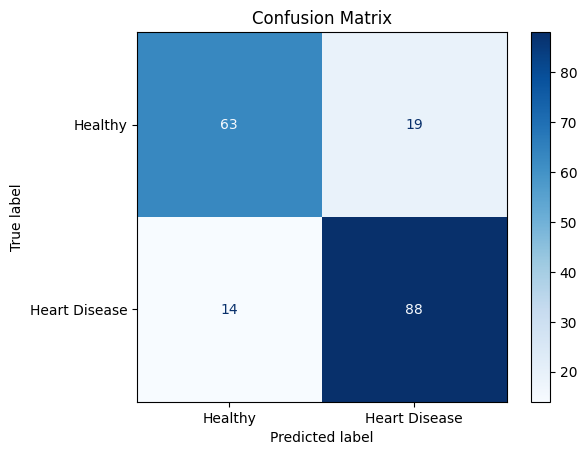


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.77      0.79        82
           1       0.82      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184

ROC-AUC: 0.892


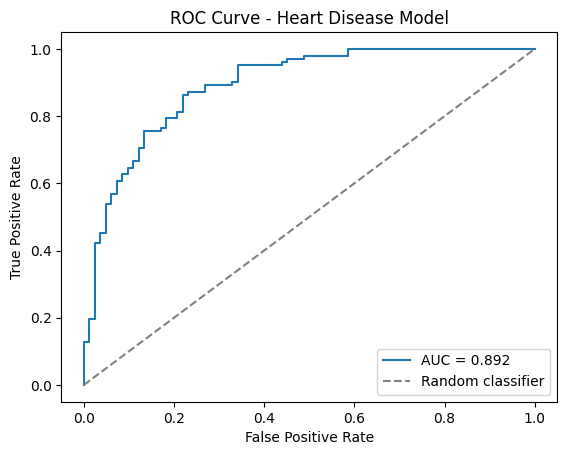

In [39]:
# Evaluation

print("=== Logistic Regression ===\n")

# Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Healthy', 'Heart Disease'],
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Heart Disease Model')
plt.legend()
plt.show()


In [40]:
# Top10 Features Importance

feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

coefficients = pipeline.named_steps['model'].coef_[0]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

importance_df['abs_coef'] = importance_df['coefficient'].abs()
importance_df = importance_df.sort_values(by='abs_coef', ascending=False)

print(importance_df.head(10))

                          feature  coefficient  abs_coef
6         cat__cp_atypical angina    -1.829250  1.829250
17                       bin__sex     1.359463  1.359463
7             cat__cp_non-anginal    -0.935348  0.935348
8          cat__cp_typical angina    -0.868750  0.868750
12                cat__slope_flat     0.807189  0.807189
19                     bin__exang     0.806558  0.806558
15               cat__thal_normal    -0.675790  0.675790
10  cat__restecg_st-t abnormality     0.531600  0.531600
5                         num__ca     0.503076  0.503076
16    cat__thal_reversable defect     0.363590  0.363590


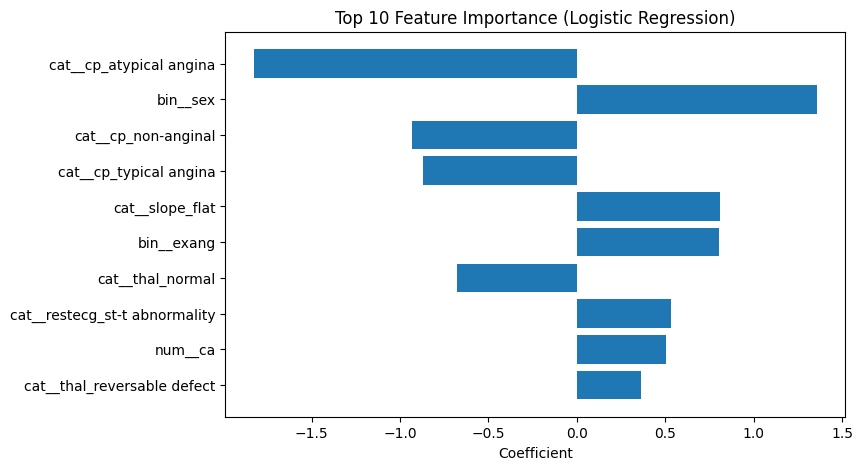

In [41]:
top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['feature'][::-1], top_features['coefficient'][::-1])
plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient")
plt.show()

# Conclusions
The logistic regression model trained on the UCI Heart Disease dataset was able to reasonably predict heart disease from the patient data.

The model achieves a good balance between accuracy and recall, making it useful for the early detection of diseases.

* Accuracy: 0.82

* Precision: 0.82

* Recall: 0.86

* F1 Score: 0.84

* ROC_AUC: 0.892

In [42]:
# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print(f'ROC_AUC: {roc_auc:.3f}')

Accuracy: 0.82
Precision: 0.82
Recall: 0.86
F1 Score: 0.84
ROC_AUC: 0.892


The coefficient analysis revealed that the variables with the greatest predictive impact were:

* Type of chest pain (cp)
* Sex (demographic factor)
* ECG abnormalities (restecg, slope)
* Exercise-induced angina (exang)
* Thalassemia-related defects (thal)
* Number of major vessels affected (ca)

Consistent with clinical literature

Limitations include significant missing values ​​for relevant variables (ca: 66%, thal: 53%), which introduces some uncertainty in the predictions.

Future work could explore models more robust to missing data (e.g., Random Forest, XGBoost) or multiple imputation techniques.

In the healthcare field, recall is especially important, since failing to detect a patient with heart disease carries greater consequences than obtaining a false positive.

improving recall should be a key objective: with Threshold = 0.44 we get recall 0.892, precision = 0.80

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Optimal threshold balancing recall with precision>=0.80: 0.44
Recall with threshold 0.44: 0.892


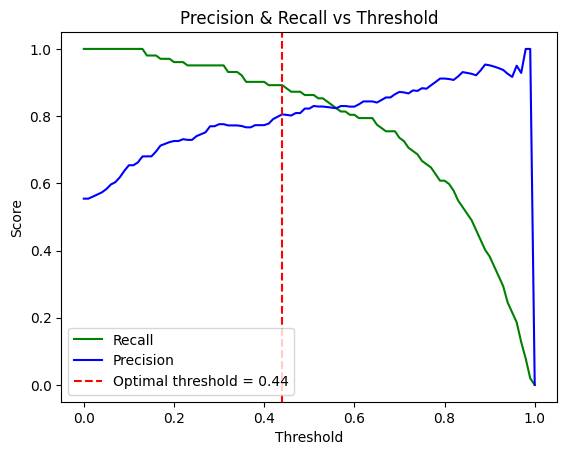

In [43]:
thresholds = np.linspace(0, 1, 101)
recalls = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Thresholds where precision ≥ 0.80
valid_idx = [i for i, p in enumerate(precisions) if p >= 0.80]

if valid_idx:
    best_idx = valid_idx[np.argmax([recalls[i] for i in valid_idx])]
    best_threshold = thresholds[best_idx]
    print(f"Optimal threshold balancing recall with precision>=0.80: {best_threshold:.2f}")  # => 0.44
else:
    print("No threshold satisfies the minimum precision constraint")

# Threshold = 0.44 = recall  0.892, precision = 0.80

threshold = 0.44
y_pred_044= (y_proba >= threshold).astype(int)
recall_044 = recall_score(y_test, y_pred_044)
print(f"Recall with threshold 0.44: {recall_044:.3f}")


plt.plot(thresholds, recalls, label='Recall', color='green')
plt.plot(thresholds, precisions, label='Precision', color='blue')
if valid_idx:
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.show()

In [44]:
print("=== Default threshold (0.5) ===")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")

print("\n=== Lower threshold (0.44) ===")
print(f"Recall: {recall_score(y_test, y_pred_044):.3f}")

=== Default threshold (0.5) ===
Recall: 0.863

=== Lower threshold (0.44) ===
Recall: 0.892
